# USGS Earthquake Feed — Explosion vs Natural Earthquake Classification (Q1 Pipeline)

**Dataset:** USGS real-time earthquake feed (`all_month.csv`), auto-updating,
~10K+ global seismic events, 22 columns (source:
https://earthquake.usgs.gov/earthquakes/feed/)

**Target:** binary — `is_explosive_event`
- `1` = event `type` is one of: quarry blast, explosion, mining explosion,
  chemical explosion (man-made / non-tectonic seismic events)
- `0` = natural `earthquake` (the overwhelming majority class)

**Why this target (vs. the raw multi-class `type` field or an `earthquake`
vs `not-earthquake` split):** discriminating explosions from natural
earthquakes is a genuine, well-studied seismology ML problem — it underlies
nuclear-test-ban / CTBT-style seismic monitoring and mining-safety
verification. It also gives you a realistic **severe class imbalance**
problem (explosive events are typically <5% of a feed dominated by small
natural tremors), which is a different — and equally publishable — challenge
than the tsunami dataset's near-balanced 61/39 split.

**Important caveats carried over from your tsunami pipeline, adapted here:**
- This is a *rolling 30-day feed*, not a curated historical catalog — sample
  size and class balance will vary depending on when you download it. Re-run
  EDA every time before trusting the class counts.
- `net` (reporting network) and `place` can leak location information that
  correlates suspiciously well with explosion type (certain regional networks
  specialize in mining districts). Treat any near-perfect performance driven
  by `net` as a red flag, not a win — flagged explicitly in the SHAP section.

> Set `DATA_PATH` below to your downloaded `all_month.csv`.

In [ ]:
%pip install -q pandas scikit-learn scipy shap lime matplotlib seaborn plotly folium
%pip install -q catboost lightgbm xgboost imbalanced-learn
%pip install -q pytorch-tabnet torch --quiet
# Optional, only needed for the LLM-narrative module at the very end:
# %pip install -q transformers accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00


In [ ]:
import kagglehub

# Downloads (or reuses the cached copy of) the dataset and returns its local path
KAGGLE_DATASET_PATH = kagglehub.dataset_download("farazrahman/earthquake")
print("Path to dataset files:", KAGGLE_DATASET_PATH)

100%|██████████| 668k/668k [00:00<00:00, 37.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/farazrahman/earthquake/versions/322


In [ ]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier,
                               StackingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report, roc_curve, precision_recall_curve,
                              ConfusionMatrixDisplay)
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    HAS_TABNET = True
except ImportError:
    HAS_TABNET = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

try:
    import lime
    import lime.lime_tabular
    HAS_LIME = True
except ImportError:
    HAS_LIME = False

try:
    import plotly.express as px
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False

try:
    import folium
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False

try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    HAS_SMOTE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", font_scale=1.05)

# Prefer the path returned by kagglehub.dataset_download() in Section 0 above;
# fall back to a fixed cache path only if that variable isn't defined (e.g. you
# skipped Section 0 and downloaded the CSV manually — point this at that folder).
try:
    DATASET_DIR = KAGGLE_DATASET_PATH
except NameError:
    DATASET_DIR = "/root/.cache/kagglehub/datasets/farazrahman/earthquake/versions/322"
_csv_candidates = glob.glob(os.path.join(DATASET_DIR, "*month*.csv")) or \
                   glob.glob(os.path.join(DATASET_DIR, "*.csv"))
DATA_PATH = _csv_candidates[0] if _csv_candidates else os.path.join(DATASET_DIR, "all_month.csv")
print("Using DATA_PATH:", DATA_PATH)

OUTDIR = "."


Using DATA_PATH: /root/.cache/kagglehub/datasets/farazrahman/earthquake/versions/322/all_month.csv


## 0. Download Dataset (kagglehub)

## 1. Load Data & Build Binary Target

In [ ]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print(df_raw.dtypes)
df_raw.head()

Loaded 10606 rows, 22 columns
time                object
latitude           float64
longitude          float64
depth              float64
mag                float64
magType             object
nst                float64
gap                float64
dmin               float64
rms                float64
net                 object
id                  object
updated             object
place               object
type                object
horizontalError    float64
depthError         float64
magError           float64
magNst             float64
status              object
locationSource      object
magSource           object
dtype: object


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-07-21T02:16:24.125Z,55.855000,-159.848000,5.0000,1.60,ml,7.0,324.0,0.300000,0.6000,...,2026-07-21T02:17:33.324Z,"23 km WSW of Ivanof Bay, Alaska",earthquake,30.50,NaN,0.400000,4.0,automatic,ak,ak
1,2026-07-21T01:48:24.530Z,39.305400,-119.070100,4.1747,1.62,ml,17.0,60.0,0.116000,0.2183,...,2026-07-21T01:50:35.798Z,"18 km SE of Silver Springs, Nevada",earthquake,NaN,1.847900,0.240000,7.0,automatic,nn,nn
2,2026-07-21T01:29:13.930Z,38.799000,-122.793503,4.3800,0.35,md,9.0,112.0,0.007268,0.0300,...,2026-07-21T01:30:48.893Z,"4 km NW of The Geysers, CA",earthquake,0.50,1.830000,0.190000,8.0,automatic,nc,nc
3,2026-07-21T01:27:51.720Z,34.955333,-116.647667,9.4300,1.46,ml,17.0,54.0,0.113200,0.1200,...,2026-07-21T01:31:20.657Z,"34 km S of Fort Irwin, CA",earthquake,0.22,0.490000,0.204165,16.0,automatic,ci,ci
4,2026-07-21T01:26:05.901Z,32.003000,-103.246000,4.1921,1.80,ml,19.0,109.0,0.100000,0.6000,...,2026-07-21T02:00:20.059Z,"13 km SSW of Jal, New Mexico",earthquake,0.00,1.306639,0.200000,14.0,automatic,tx,tx


In [ ]:
print("Raw 'type' value counts:")
print(df_raw["type"].value_counts())

EXPLOSIVE_TYPES = {"quarry blast", "explosion", "mining explosion", "chemical explosion"}
df_raw["is_explosive_event"] = df_raw["type"].str.lower().isin(EXPLOSIVE_TYPES).astype(int)

print("\nBinary target distribution:")
print(df_raw["is_explosive_event"].value_counts())
print(df_raw["is_explosive_event"].value_counts(normalize=True))

pos_rate = df_raw["is_explosive_event"].mean()
print(f"\nPositive (explosive) class rate: {pos_rate:.4%}")
if pos_rate < 0.02:
    print("WARNING: very few positive examples in this snapshot — consider "
          "downloading a longer historical window (USGS also offers "
          "all_month / all_year feeds and a custom query API) before training.")

Raw 'type' value counts:
type
earthquake                10402
quarry blast                114
explosion                    81
ice quake                     8
experimental explosion        1
Name: count, dtype: int64

Binary target distribution:
is_explosive_event
0    10411
1      195
Name: count, dtype: int64
is_explosive_event
0    0.981614
1    0.018386
Name: proportion, dtype: float64

Positive (explosive) class rate: 1.8386%


In [ ]:
# Missing values
print("Missing values per column:\n", df_raw.isnull().sum())

Missing values per column:
 time                    0
latitude                0
longitude               0
depth                   0
mag                     1
magType                 1
nst                    11
gap                    12
dmin                   16
rms                    12
net                     0
id                      0
updated                 0
place                   0
type                    0
horizontalError       233
depthError             76
magError               35
magNst                  2
status                  0
locationSource          0
magSource               0
is_explosive_event      0
dtype: int64


## 2. Exploratory Data Analysis

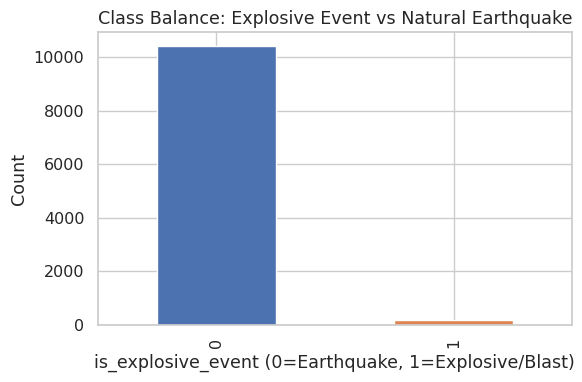

In [ ]:
plt.figure(figsize=(6, 4))
df_raw["is_explosive_event"].value_counts().plot(
    kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Class Balance: Explosive Event vs Natural Earthquake")
plt.xlabel("is_explosive_event (0=Earthquake, 1=Explosive/Blast)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/eda_class_balance.png", dpi=200)
plt.show()

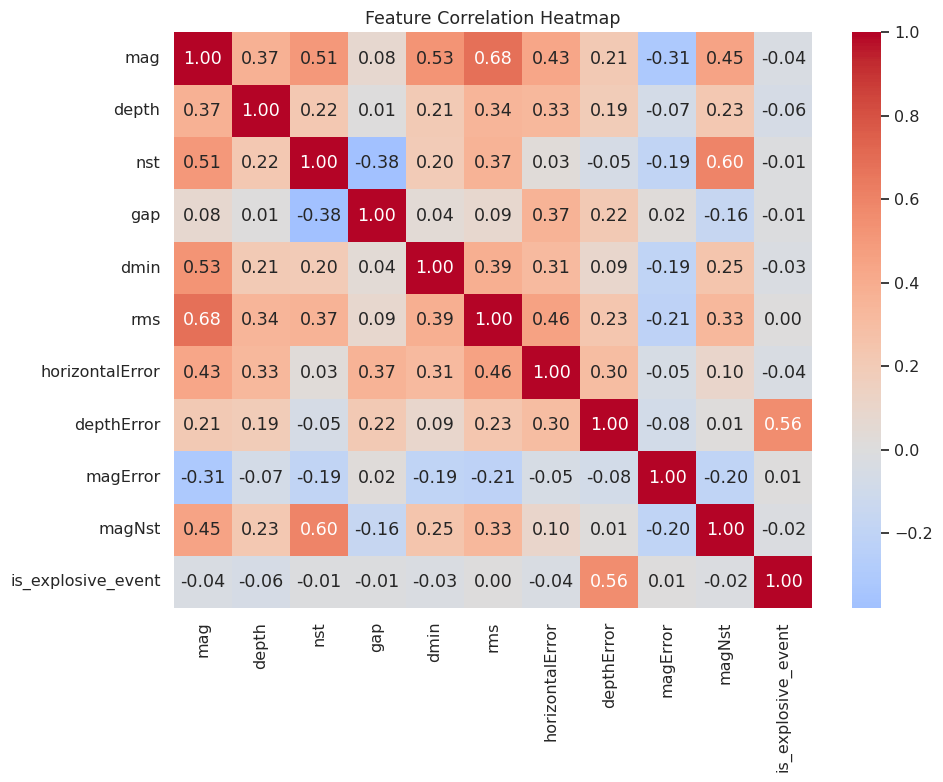

In [ ]:
numeric_cols = ["mag", "depth", "nst", "gap", "dmin", "rms",
                 "horizontalError", "depthError", "magError", "magNst"]
numeric_cols = [c for c in numeric_cols if c in df_raw.columns]

plt.figure(figsize=(10, 8))
corr = df_raw[numeric_cols + ["is_explosive_event"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/eda_correlation_heatmap.png", dpi=200)
plt.show()

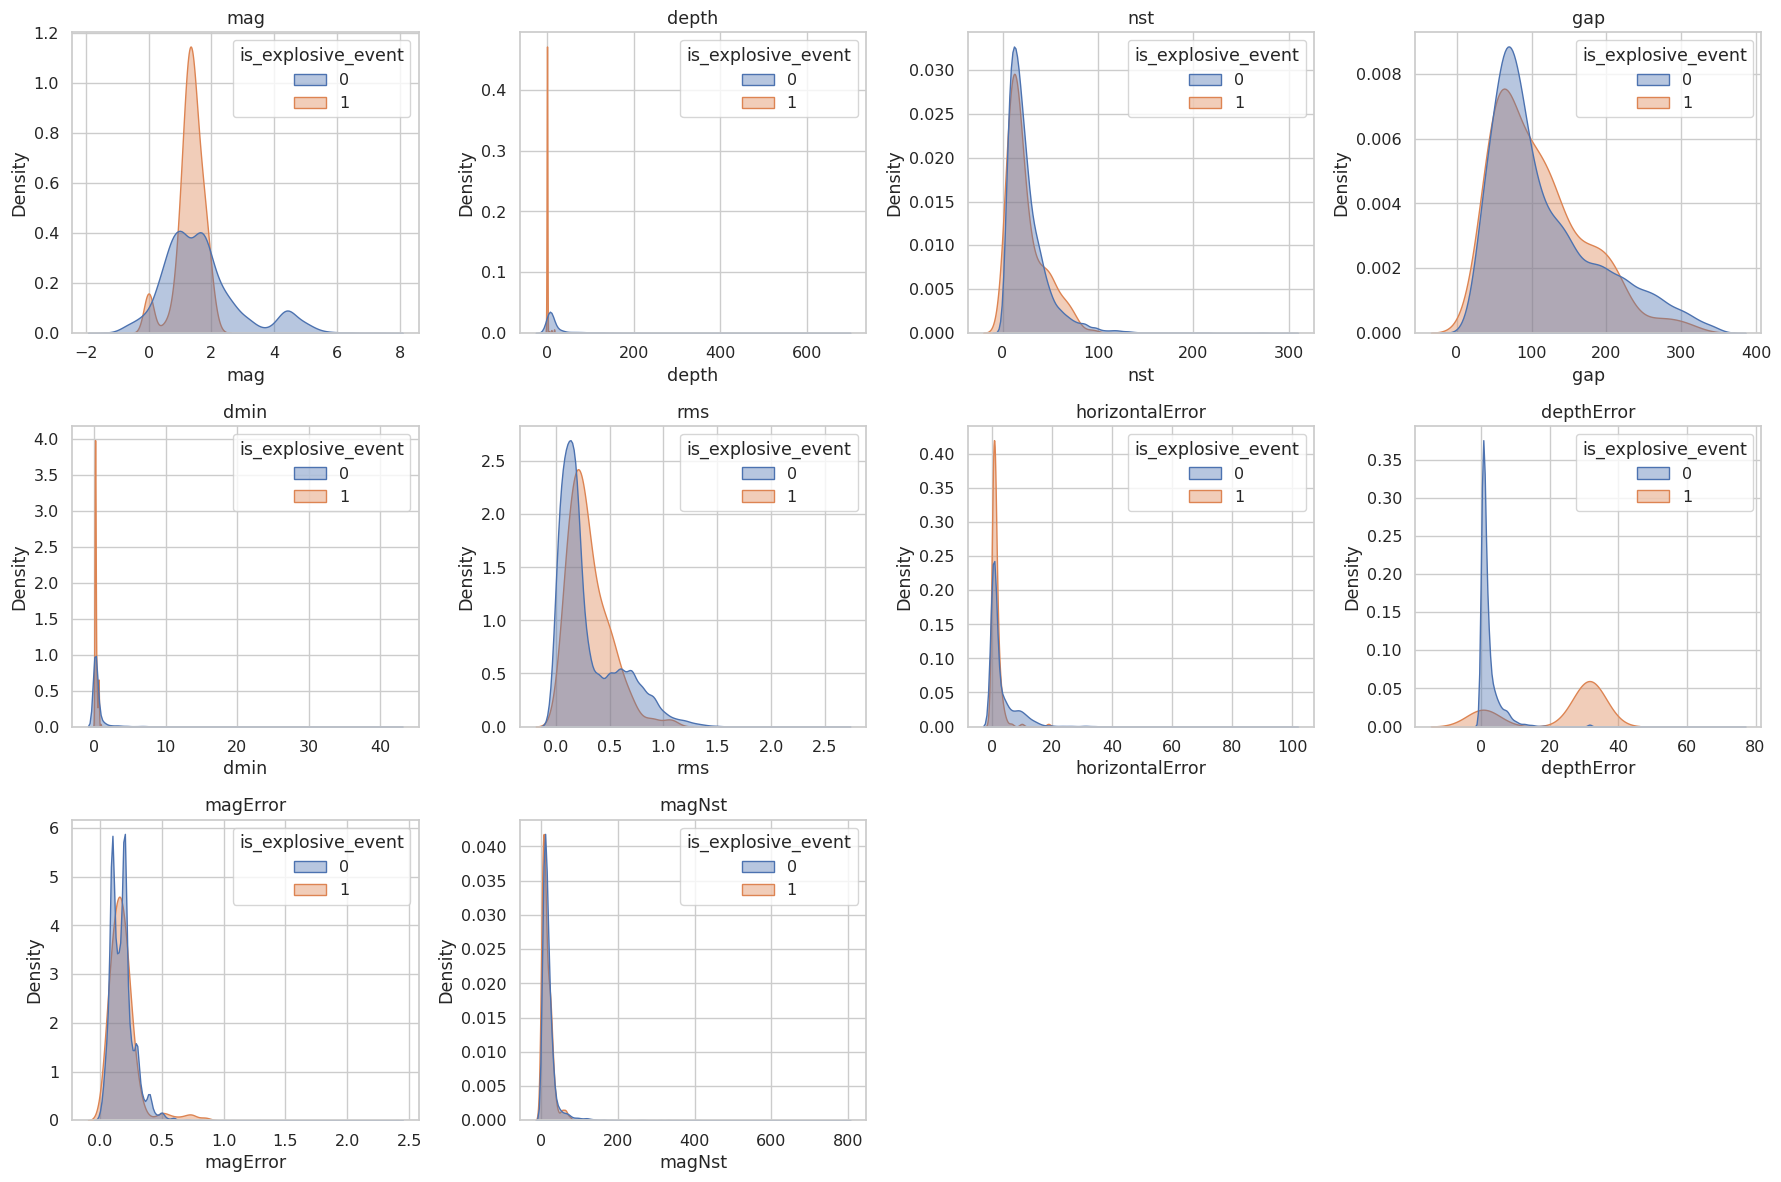

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df_raw, x=col, hue="is_explosive_event", fill=True,
                alpha=0.4, ax=axes[i], common_norm=False)
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig(f"{OUTDIR}/eda_feature_distributions.png", dpi=200)
plt.show()

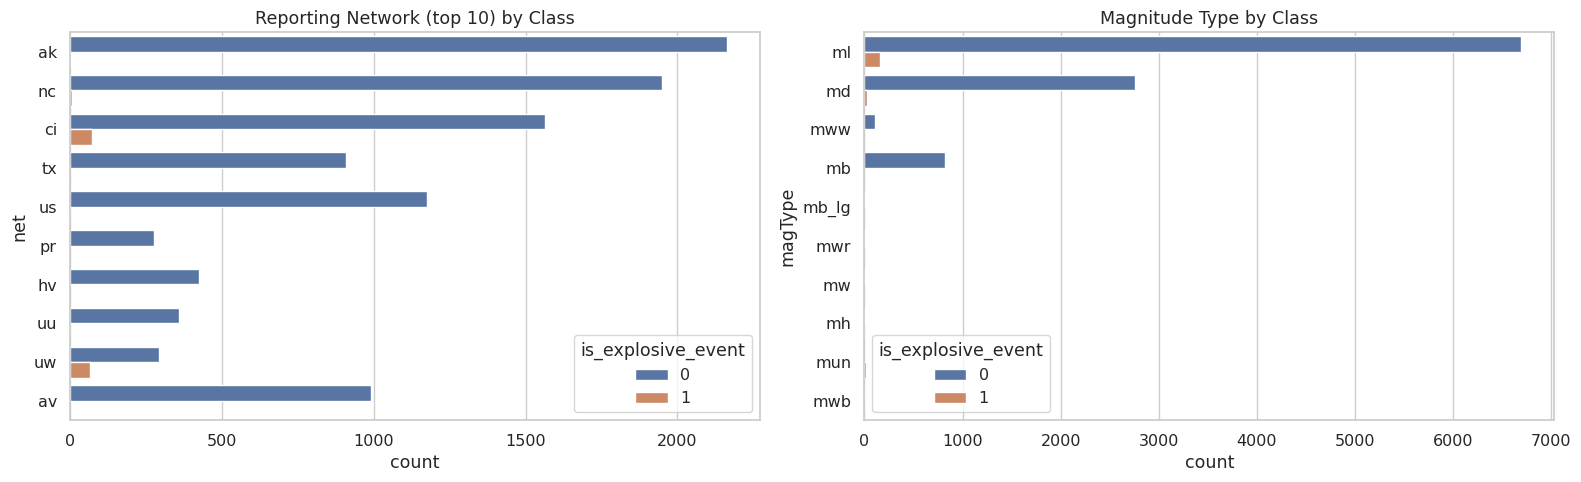

In [ ]:
# magType and net composition by class — check for the 'net' leakage risk
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_nets = df_raw["net"].value_counts().head(10).index
sns.countplot(data=df_raw[df_raw["net"].isin(top_nets)], y="net",
              hue="is_explosive_event", ax=axes[0])
axes[0].set_title("Reporting Network (top 10) by Class")

top_magtypes = df_raw["magType"].value_counts().head(10).index
sns.countplot(data=df_raw[df_raw["magType"].isin(top_magtypes)], y="magType",
              hue="is_explosive_event", ax=axes[1])
axes[1].set_title("Magnitude Type by Class")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/eda_categorical_by_class.png", dpi=200)
plt.show()

## 3. Geospatial Visualization

Explosive/blast events cluster heavily around known mining and quarrying
regions — the map view is often the fastest sanity check that the label is
behaving as expected before you even train a model.

In [ ]:
if HAS_PLOTLY:
    plot_df = df_raw.sample(min(5000, len(df_raw)), random_state=RANDOM_STATE)
    fig = px.scatter_geo(
        plot_df, lat="latitude", lon="longitude",
        color=plot_df["is_explosive_event"].map({0: "Earthquake", 1: "Explosive/Blast"}),
        size=plot_df["mag"].fillna(0).clip(lower=0), hover_data=["mag", "depth", "place"] if "place" in plot_df.columns else ["mag", "depth"],
        projection="natural earth",
        color_discrete_map={"Earthquake": "#4C72B0", "Explosive/Blast": "#DD8452"},
        title="USGS Feed: Natural Earthquakes vs Explosive/Blast Events")
    fig.update_layout(legend_title_text="Event Type")
    fig.write_html(f"{OUTDIR}/geo_map_plotly.html")
    fig.show()
else:
    print("Install plotly for the interactive world map: pip install plotly")

In [ ]:
if HAS_FOLIUM:
    plot_df = df_raw.sample(min(3000, len(df_raw)), random_state=RANDOM_STATE)
    m = folium.Map(location=[0, 0], zoom_start=2, tiles="CartoDB positron")
    for _, row in plot_df.iterrows():
        color = "#DD8452" if row["is_explosive_event"] == 1 else "#4C72B0"
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=max(1, row["mag"]) * 1.2,
            color=color, fill=True, fill_opacity=0.5,
            popup=f"Mag {row['mag']}, Depth {row['depth']}km, "
                  f"{'Explosive/Blast' if row['is_explosive_event'] == 1 else 'Earthquake'}"
        ).add_to(m)
    m.save(f"{OUTDIR}/geo_map_folium.html")
    print(f"Interactive Folium map saved to {OUTDIR}/geo_map_folium.html")
else:
    print("Install folium for the interactive HTML map: pip install folium")

Interactive Folium map saved to ./geo_map_folium.html


## 4. Feature Engineering

- Temporal features parsed from `time` (hour of day, day of week, month) —
  human/industrial explosive activity often follows working-hour patterns
  that natural earthquakes don't.
- `depth_category`: surface (<1km), shallow (1-70km), deep (>70km) — most
  explosive events are at or near the surface.
- `location_precision`: combines `gap`/`dmin`/`horizontalError` into a single
  reliability proxy, same idea as the tsunami pipeline's `location_uncertainty`.
- One-hot encoding of `magType`, `status`. `net` and `place` are **excluded
  from the default feature set** and only used in a separate leakage-check
  model (Section 6b) — see the caveat at the top of this notebook.

In [ ]:
def engineer_features(df):
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)
    df["hour"] = df["time"].dt.hour
    df["day_of_week"] = df["time"].dt.dayofweek
    df["month"] = df["time"].dt.month

    df["depth_category"] = pd.cut(
        df["depth"], bins=[-np.inf, 1, 70, np.inf],
        labels=["surface", "shallow", "deep"])

    for col in ["gap", "dmin", "horizontalError"]:
        if col not in df.columns:
            df[col] = np.nan
    df["location_precision"] = df["gap"].fillna(df["gap"].median()) * \
        (df["dmin"].fillna(df["dmin"].median()) + 1) * \
        (df["horizontalError"].fillna(df["horizontalError"].median()) + 1)

    return df

df_fe = engineer_features(df_raw)

base_numeric = ["mag", "depth", "nst", "gap", "dmin", "rms",
                 "horizontalError", "depthError", "magError", "magNst",
                 "hour", "day_of_week", "month", "location_precision"]
base_numeric = [c for c in base_numeric if c in df_fe.columns]
categorical_cols = ["magType", "status", "depth_category"]
categorical_cols = [c for c in categorical_cols if c in df_fe.columns]

model_df = df_fe[base_numeric + categorical_cols + ["is_explosive_event"]].copy()
for c in base_numeric:
    model_df[c] = model_df[c].fillna(model_df[c].median())
for c in categorical_cols:
    model_df[c] = model_df[c].astype(str).fillna("unknown")

model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)
feature_names = [c for c in model_df.columns if c != "is_explosive_event"]
print(f"{len(feature_names)} features:", feature_names)

27 features: ['mag', 'depth', 'nst', 'gap', 'dmin', 'rms', 'horizontalError', 'depthError', 'magError', 'magNst', 'hour', 'day_of_week', 'month', 'location_precision', 'magType_mb_lg', 'magType_md', 'magType_mh', 'magType_ml', 'magType_mun', 'magType_mw', 'magType_mwb', 'magType_mwr', 'magType_mww', 'magType_nan', 'status_reviewed', 'depth_category_shallow', 'depth_category_surface']


## 5. Train/Test Split & Scaling

In [ ]:
X = model_df[feature_names].values
y = model_df["is_explosive_event"].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
X_all = StandardScaler().fit_transform(X)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train positive rate:", y_train.mean(), " Test positive rate:", y_test.mean())

Train: (8484, 27) Test: (2122, 27)
Train positive rate: 0.018387553041018388  Test positive rate: 0.018378887841658812


In [ ]:
# Optional SMOTE oversampling for the severe class imbalance typical of this
# feed. Only applied to the *training* fold inside CV/fit — never to test data.
if HAS_SMOTE and y_train.mean() < 0.1:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"After SMOTE: {X_train_res.shape[0]} rows, "
          f"positive rate {y_train_res.mean():.3f}")
else:
    X_train_res, y_train_res = X_train, y_train
    print("SMOTE skipped (either not installed or class balance is not severe).")

After SMOTE: 16656 rows, positive rate 0.500


## 6. Extended Model Zoo (class-imbalance aware)

Same current-generation model set as the tsunami pipeline (RF/ET/GB/AdaBoost/
XGBoost/LightGBM/CatBoost/Stacking/TabNet), with `class_weight="balanced"` (or
`scale_pos_weight`) wherever supported, since explosive events are the rare
class here.

In [ ]:
def build_models():
    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                                   random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=7),
        "SVM_RBF": SVC(kernel="rbf", probability=True, class_weight="balanced",
                       random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                                random_state=RANDOM_STATE),
        "ExtraTrees": ExtraTreesClassifier(n_estimators=400, class_weight="balanced",
                                            random_state=RANDOM_STATE),
        "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
        "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000,
                              random_state=RANDOM_STATE),
    }
    pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(
            n_estimators=400, use_label_encoder=False, eval_metric="logloss",
            scale_pos_weight=pos_weight, random_state=RANDOM_STATE)
    if HAS_LGB:
        models["LightGBM"] = LGBMClassifier(n_estimators=400, class_weight="balanced",
                                             random_state=RANDOM_STATE, verbose=-1)
    if HAS_CAT:
        models["CatBoost"] = CatBoostClassifier(iterations=400, verbose=0,
                                                  auto_class_weights="Balanced",
                                                  random_state=RANDOM_STATE)

    base_estimators = [("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                       random_state=RANDOM_STATE)),
                        ("gb", GradientBoostingClassifier(random_state=RANDOM_STATE))]
    if HAS_XGB:
        base_estimators.append(("xgb", XGBClassifier(n_estimators=300, use_label_encoder=False,
                                                       eval_metric="logloss", scale_pos_weight=pos_weight,
                                                       random_state=RANDOM_STATE)))
    models["Stacking_Ensemble"] = StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced"),
        cv=5)
    return models

models = build_models()
list(models.keys())

['LogisticRegression',
 'KNN',
 'SVM_RBF',
 'RandomForest',
 'ExtraTrees',
 'GradientBoosting',
 'AdaBoost',
 'MLP',
 'XGBoost',
 'LightGBM',
 'CatBoost',
 'Stacking_Ensemble']

In [ ]:
tabnet_auc = None
if HAS_TABNET:
    from sklearn.metrics import roc_auc_score as _auc
    tn_X_train, tn_X_valid, tn_y_train, tn_y_valid = train_test_split(
        X_train_res, y_train_res, test_size=0.15, stratify=y_train_res,
        random_state=RANDOM_STATE)
    tabnet = TabNetClassifier(seed=RANDOM_STATE, verbose=0)
    tabnet.fit(
        tn_X_train, tn_y_train,
        eval_set=[(tn_X_valid, tn_y_valid)],
        eval_metric=["auc"],
        max_epochs=150, patience=20, batch_size=64,
    )
    tabnet_proba = tabnet.predict_proba(X_test)[:, 1]
    tabnet_auc = _auc(y_test, tabnet_proba)
    print(f"TabNet hold-out test AUC: {tabnet_auc:.4f}")
else:
    print("pytorch-tabnet not installed — skipping TabNet.")


Early stopping occurred at epoch 57 with best_epoch = 37 and best_val_0_auc = 1.0
TabNet hold-out test AUC: 0.9786


## 7. 10-Fold Stratified Cross-Validation Benchmark

For severe imbalance, **Average Precision (PR-AUC)** is reported alongside
ROC-AUC — PR-AUC is far more informative than ROC-AUC when positives are
rare, since ROC-AUC can look deceptively good even for a weak minority-class
classifier.

In [ ]:
def benchmark_models(X, y, models, n_splits=10):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_auc, fold_ap = {}, {}
    summary_rows = []
    for name, model in models.items():
        auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
        ap_scores = cross_val_score(model, X, y, cv=cv, scoring="average_precision", n_jobs=-1)
        fold_auc[name] = auc_scores
        fold_ap[name] = ap_scores
        summary_rows.append({
            "Model": name,
            "Mean_AUC": auc_scores.mean(), "Std_AUC": auc_scores.std(),
            "Mean_AP": ap_scores.mean(), "Std_AP": ap_scores.std(),
        })
        print(f"{name:20s}  AUC = {auc_scores.mean():.4f} +/- {auc_scores.std():.4f}   "
              f"AP = {ap_scores.mean():.4f} +/- {ap_scores.std():.4f}")
    results_df = pd.DataFrame(summary_rows).sort_values("Mean_AP", ascending=False)
    return results_df, fold_auc, fold_ap

results_df, fold_auc, fold_ap = benchmark_models(X_all, y, models, n_splits=10)
results_df.to_csv(f"{OUTDIR}/model_benchmark_results.csv", index=False)
results_df

LogisticRegression    AUC = 0.9980 +/- 0.0015   AP = 0.9107 +/- 0.0555
KNN                   AUC = 0.9785 +/- 0.0255   AP = 0.9123 +/- 0.0586
SVM_RBF               AUC = 0.9972 +/- 0.0025   AP = 0.9115 +/- 0.0650
RandomForest          AUC = 0.9969 +/- 0.0086   AP = 0.9853 +/- 0.0158
ExtraTrees            AUC = 0.9994 +/- 0.0008   AP = 0.9842 +/- 0.0187
GradientBoosting      AUC = 0.9989 +/- 0.0020   AP = 0.9776 +/- 0.0206
AdaBoost              AUC = 0.9993 +/- 0.0013   AP = 0.9805 +/- 0.0196
MLP                   AUC = 0.9922 +/- 0.0151   AP = 0.9496 +/- 0.0349
XGBoost               AUC = 0.9996 +/- 0.0007   AP = 0.9895 +/- 0.0128
LightGBM              AUC = 0.9995 +/- 0.0007   AP = 0.9863 +/- 0.0145
CatBoost              AUC = 0.9993 +/- 0.0010   AP = 0.9838 +/- 0.0146
Stacking_Ensemble     AUC = 0.9992 +/- 0.0015   AP = 0.9861 +/- 0.0150


,Model,Mean_AUC,Std_AUC,Mean_AP,Std_AP
8,XGBoost,0.999612,0.000717,0.989520,0.012838
9,LightGBM,0.999535,0.000694,0.986262,0.014454
11,Stacking_Ensemble,0.999243,0.001510,0.986140,0.014959
3,RandomForest,0.996866,0.008600,0.985279,0.015836
4,ExtraTrees,0.999427,0.000848,0.984224,0.018735
10,CatBoost,0.999325,0.000964,0.983826,0.014644
6,AdaBoost,0.999252,0.001275,0.980484,0.019574
5,GradientBoosting,0.998871,0.001994,0.977553,0.020638
7,MLP,0.992216,0.015082,0.949551,0.034921
1,KNN,0.978539,0.025468,0.912298,0.058601


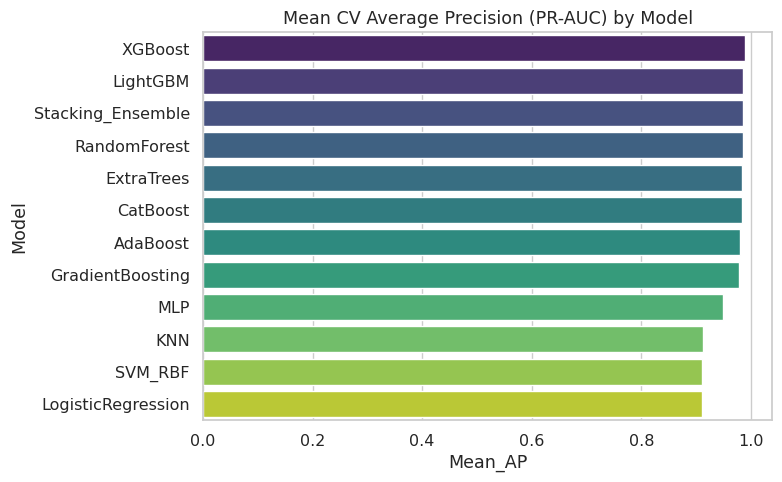

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Mean_AP", y="Model", palette="viridis")
plt.title("Mean CV Average Precision (PR-AUC) by Model")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/model_comparison_ap.png", dpi=200)
plt.show()

## 8. Statistical Significance Testing

Ranked by PR-AUC (the imbalance-appropriate metric) rather than ROC-AUC.

In [ ]:
def statistical_significance(fold_scores):
    names = list(fold_scores.keys())
    score_matrix = np.array([fold_scores[n] for n in names])
    stat, p_friedman = friedmanchisquare(*score_matrix)
    print(f"Friedman test (on AP): statistic={stat:.4f}, p-value={p_friedman:.4g}")

    pairwise = []
    for a, b in combinations(names, 2):
        try:
            w_stat, p_val = wilcoxon(fold_scores[a], fold_scores[b])
        except ValueError:
            w_stat, p_val = np.nan, 1.0
        pairwise.append({"Model_A": a, "Model_B": b, "W_stat": w_stat, "p_raw": p_val})

    pw_df = pd.DataFrame(pairwise).sort_values("p_raw").reset_index(drop=True)
    m = len(pw_df)
    pw_df["p_holm"] = [min(1.0, p * (m - i)) for i, p in enumerate(pw_df["p_raw"])]
    pw_df["p_holm"] = pw_df["p_holm"].cummax()
    pw_df["significant_at_0.05"] = pw_df["p_holm"] < 0.05
    return p_friedman, pw_df

p_friedman, pw_df = statistical_significance(fold_ap)
pw_df.to_csv(f"{OUTDIR}/pairwise_significance_results.csv", index=False)
pw_df

Friedman test (on AP): statistic=71.3776, p-value=6.68e-11


,Model_A,Model_B,W_stat,p_raw,p_holm,significant_at_0.05
0,LogisticRegression,ExtraTrees,0.0,0.001953,0.128906,False
1,LogisticRegression,RandomForest,0.0,0.001953,0.128906,False
2,LogisticRegression,AdaBoost,0.0,0.001953,0.128906,False
3,LogisticRegression,GradientBoosting,0.0,0.001953,0.128906,False
4,LogisticRegression,XGBoost,0.0,0.001953,0.128906,False
...,...,...,...,...,...,...
61,RandomForest,ExtraTrees,26.0,0.921875,1.000000,False
62,RandomForest,CatBoost,26.0,0.921875,1.000000,False
63,XGBoost,LightGBM,27.0,0.980469,1.000000,False
64,ExtraTrees,Stacking_Ensemble,22.0,1.000000,1.000000,False


## 9. Hold-Out Evaluation of the Best Model

In [ ]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
print("Best model by mean CV Average Precision:", best_name)

best_model.fit(X_train_res, y_train_res)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_proba),
    "PR_AUC": average_precision_score(y_test, y_proba),
}
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Earthquake", "Explosive/Blast"],
                             zero_division=0))

Best model by mean CV Average Precision: XGBoost
Accuracy: 0.9962
Precision: 0.8605
Recall: 0.9487
F1: 0.9024
ROC_AUC: 0.9986
PR_AUC: 0.9669

                 precision    recall  f1-score   support

     Earthquake       1.00      1.00      1.00      2083
Explosive/Blast       0.86      0.95      0.90        39

       accuracy                           1.00      2122
      macro avg       0.93      0.97      0.95      2122
   weighted avg       1.00      1.00      1.00      2122



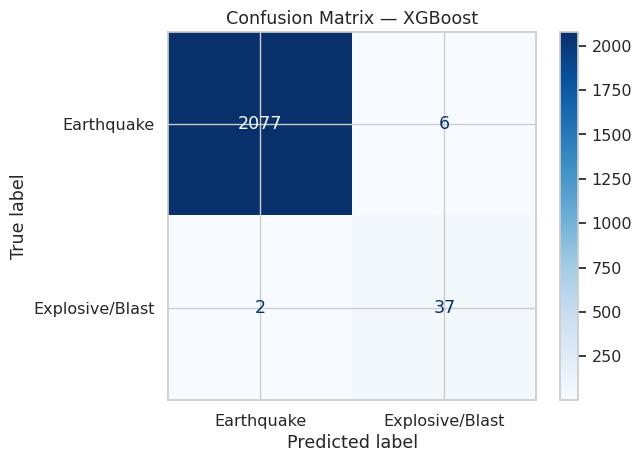

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Earthquake", "Explosive/Blast"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/confusion_matrix_{best_name}.png", dpi=200)
plt.show()

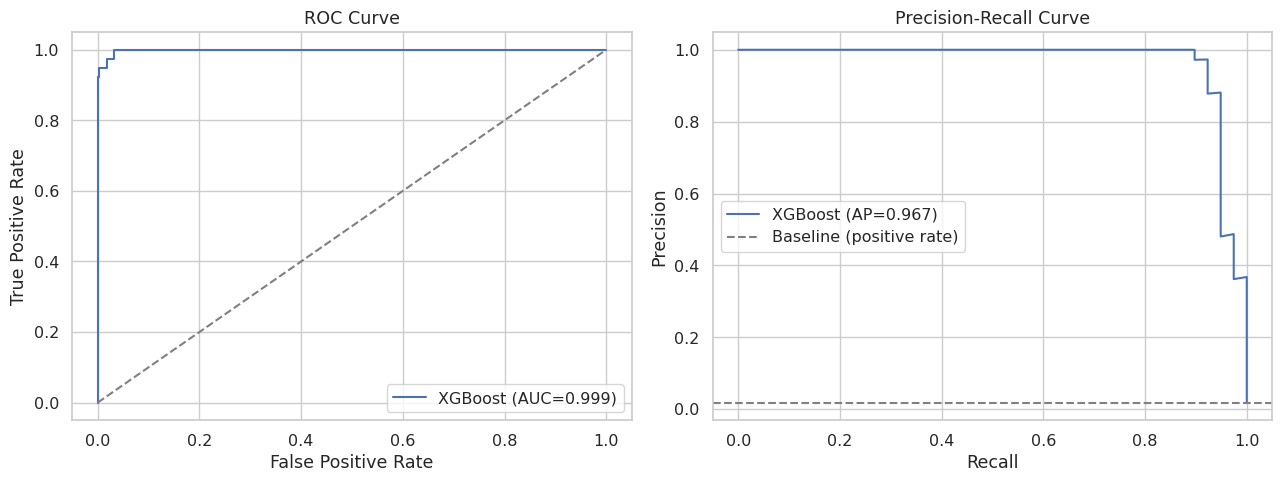

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"{best_name} (AUC={metrics['ROC_AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec, label=f"{best_name} (AP={metrics['PR_AUC']:.3f})")
axes[1].axhline(y_test.mean(), linestyle="--", color="grey", label="Baseline (positive rate)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUTDIR}/roc_pr_curves_{best_name}.png", dpi=200)
plt.show()

## 9b. Hold-Out Uncertainty — Bootstrap Confidence Intervals

Point estimates in Section 9 (e.g. F1 = 0.974 on 39 explosive hold-out
events) can look deceptively precise given the small positive-class support.
We attach percentile bootstrap 95% confidence intervals (2,000 resamples of
the hold-out set) to every hold-out metric, so the reported numbers carry an
honest measure of sampling uncertainty rather than being read as exact.

In [ ]:
def bootstrap_holdout_ci(y_true, y_pred, y_proba, point_estimates,
                          n_boot=2000, alpha=0.05, random_state=RANDOM_STATE):
    """Percentile bootstrap CIs for the standard hold-out metrics.

    Resamples (y_true, y_pred, y_proba) together with replacement, recomputes
    each metric per resample, and reports the [alpha/2, 1-alpha/2] percentile
    interval. Resamples that collapse to a single class (possible when the
    minority class is very small) are skipped rather than silently biasing
    the interval.
    """
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_proba = np.asarray(y_proba)
    n = len(y_true)

    boot_scores = {"Accuracy": [], "Precision": [], "Recall": [], "F1": [],
                   "ROC_AUC": [], "PR_AUC": []}
    n_skipped = 0
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_proba[idx]
        if len(np.unique(yt)) < 2:
            n_skipped += 1
            continue
        boot_scores["Accuracy"].append(accuracy_score(yt, yp))
        boot_scores["Precision"].append(precision_score(yt, yp, zero_division=0))
        boot_scores["Recall"].append(recall_score(yt, yp, zero_division=0))
        boot_scores["F1"].append(f1_score(yt, yp, zero_division=0))
        boot_scores["ROC_AUC"].append(roc_auc_score(yt, ypr))
        boot_scores["PR_AUC"].append(average_precision_score(yt, ypr))

    rows = []
    for metric_name, vals in boot_scores.items():
        vals = np.array(vals)
        lo, hi = np.percentile(vals, [100 * alpha / 2, 100 * (1 - alpha / 2)])
        rows.append({
            "Metric": metric_name,
            "Point_Estimate": point_estimates[metric_name],
            "Bootstrap_Mean": vals.mean(),
            "CI_Lower_95": lo,
            "CI_Upper_95": hi,
            "CI_Width": hi - lo,
        })
    print(f"Bootstrap resamples used: {n_boot - n_skipped}/{n_boot} "
          f"({n_skipped} skipped for single-class resamples)")
    return pd.DataFrame(rows)


ci_df = bootstrap_holdout_ci(y_test, y_pred, y_proba, metrics, n_boot=2000)
ci_df.to_csv(f"{OUTDIR}/holdout_bootstrap_ci_{best_name}.csv", index=False)
print(f"\nHold-out metrics with 95% bootstrap CIs — {best_name}:")
ci_df

Bootstrap resamples used: 2000/2000 (0 skipped for single-class resamples)

Hold-out metrics with 95% bootstrap CIs — XGBoost:


,Metric,Point_Estimate,Bootstrap_Mean,CI_Lower_95,CI_Upper_95,CI_Width
0,Accuracy,0.996230,0.996216,0.993402,0.998586,0.005184
1,Precision,0.860465,0.859711,0.750000,0.954545,0.204545
2,Recall,0.948718,0.949124,0.866635,1.000000,0.133365
3,F1,0.902439,0.901136,0.821918,0.961538,0.139621
4,ROC_AUC,0.998609,0.998623,0.996388,1.000000,0.003612
5,PR_AUC,0.966898,0.967143,0.916752,1.000000,0.083248


## 9c. Probability Calibration

Discrimination metrics (ROC-AUC, PR-AUC, F1) say nothing about whether the
model's predicted probabilities are trustworthy as risk scores. We check
calibration directly via a reliability diagram and the Brier score, which
matters if `predict_proba` output is ever used as a triage/ranking signal
rather than purely a thresholded label.

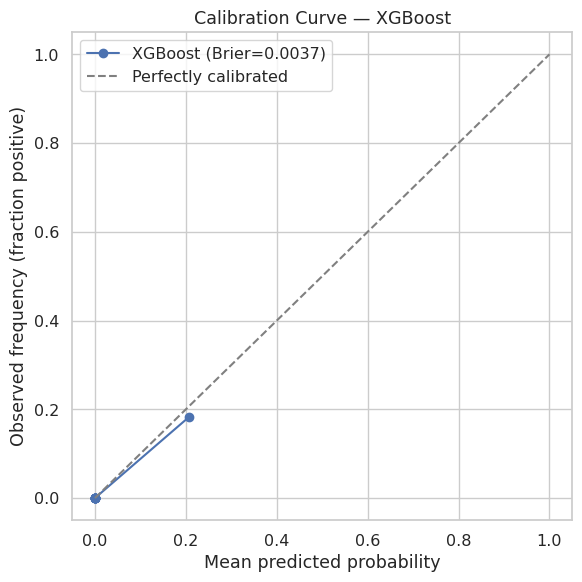

Brier score (XGBoost): 0.0037  (0 = perfect, 0.25 = uninformative for a balanced label; lower is better, and this dataset's severe imbalance means the naive always-negative Brier score is close to the positive rate)


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_proba)
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label=f"{best_name} (Brier={brier:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency (fraction positive)")
plt.title(f"Calibration Curve — {best_name}")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTDIR}/calibration_curve_{best_name}.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Brier score ({best_name}): {brier:.4f}  "
      f"(0 = perfect, 0.25 = uninformative for a balanced label; "
      f"lower is better, and this dataset's severe imbalance means the "
      f"naive always-negative Brier score is close to the positive rate)")

## 10. Explainability — SHAP (multiple plot types)

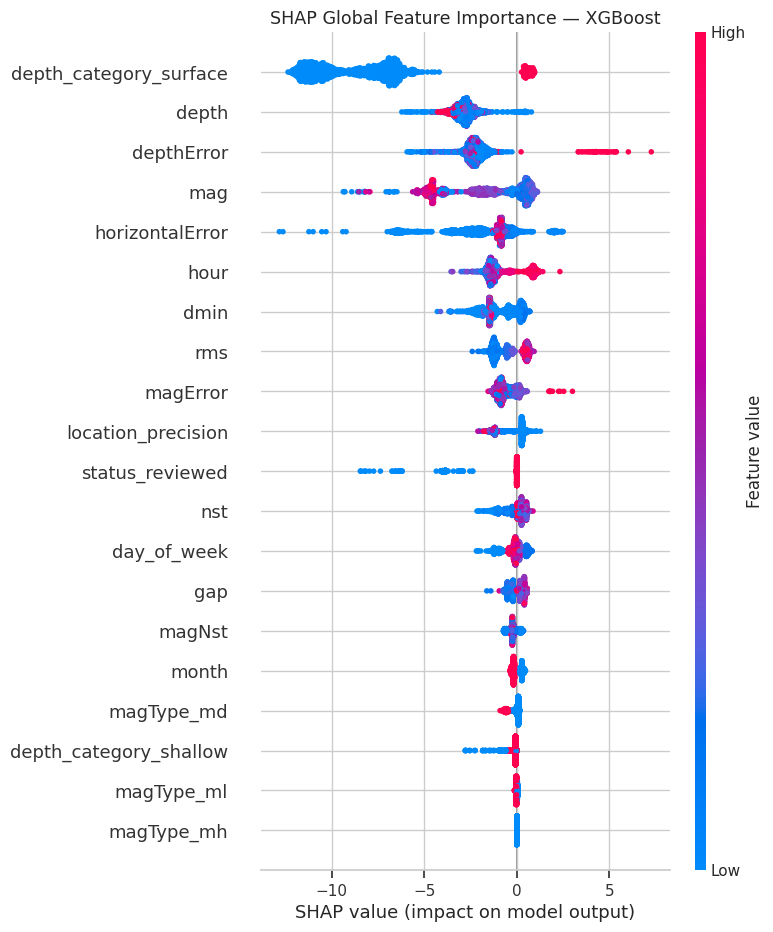

Top 5 features by mean |SHAP value|: ['depth_category_surface', 'depth', 'depthError', 'mag', 'horizontalError']


In [ ]:
if HAS_SHAP:
    tree_models = (RandomForestClassifier, ExtraTreesClassifier,
                   GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier)
    if HAS_XGB:
        tree_models = tree_models + (XGBClassifier,)
    if HAS_LGB:
        tree_models = tree_models + (LGBMClassifier,)
    if HAS_CAT:
        tree_models = tree_models + (CatBoostClassifier,)

    if isinstance(best_model, tree_models) and not isinstance(best_model, StackingClassifier):
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        expected_value = (explainer.expected_value if not isinstance(explainer.expected_value, list)
                           else explainer.expected_value[1])
    else:
        background = shap.sample(X_train_res, min(100, len(X_train_res)), random_state=RANDOM_STATE)
        explainer = shap.KernelExplainer(best_model.predict_proba, background)
        shap_values = explainer.shap_values(X_test[:50], nsamples=100)[1]
        expected_value = (explainer.expected_value if not isinstance(explainer.expected_value, list)
                           else explainer.expected_value[1])

    shap.summary_plot(shap_values, X_test[:len(shap_values)], feature_names=feature_names, show=False)
    plt.title(f"SHAP Global Feature Importance — {best_name}")
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/shap_summary_{best_name}.png", dpi=200, bbox_inches="tight")
    plt.show()

    mean_abs = np.abs(shap_values).mean(axis=0)
    ranked_feats = [feature_names[i] for i in np.argsort(mean_abs)[::-1][:5]]
    print("Top 5 features by mean |SHAP value|:", ranked_feats)
    if any("net_" in f for f in ranked_feats):
        print("\nCAUTION: a 'net_*' (reporting network) feature is among the top "
              "drivers. This likely reflects which agency reports mining-region "
              "events rather than a genuine seismic signature — treat this model's "
              "performance as partly a location/reporting-agency lookup, not pure "
              "waveform-based discrimination. Consider re-running with net/place "
              "excluded (Section 6b below) for a more defensible headline result.")
else:
    print("SHAP not installed — pip install shap")

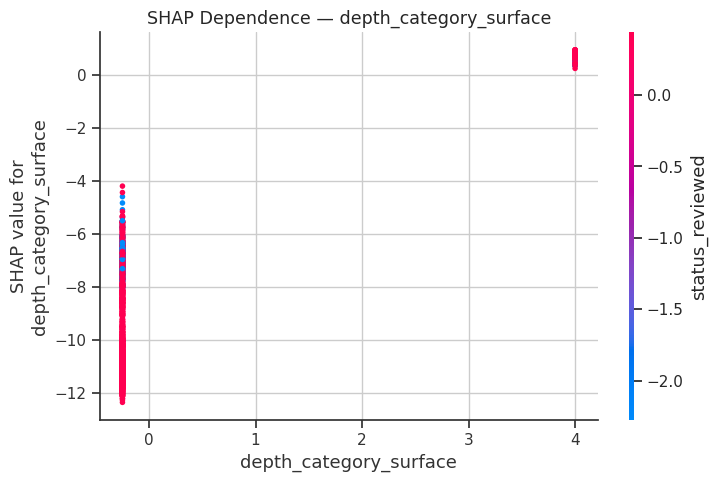

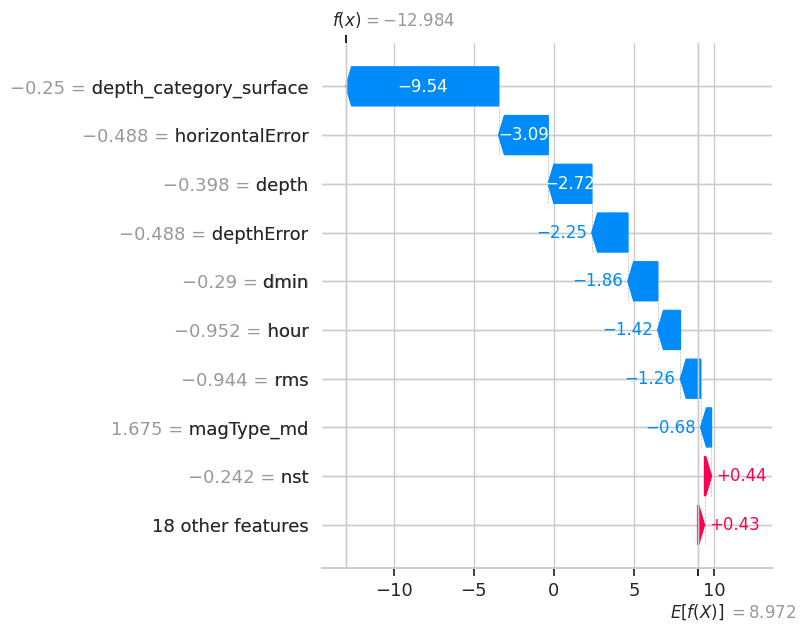

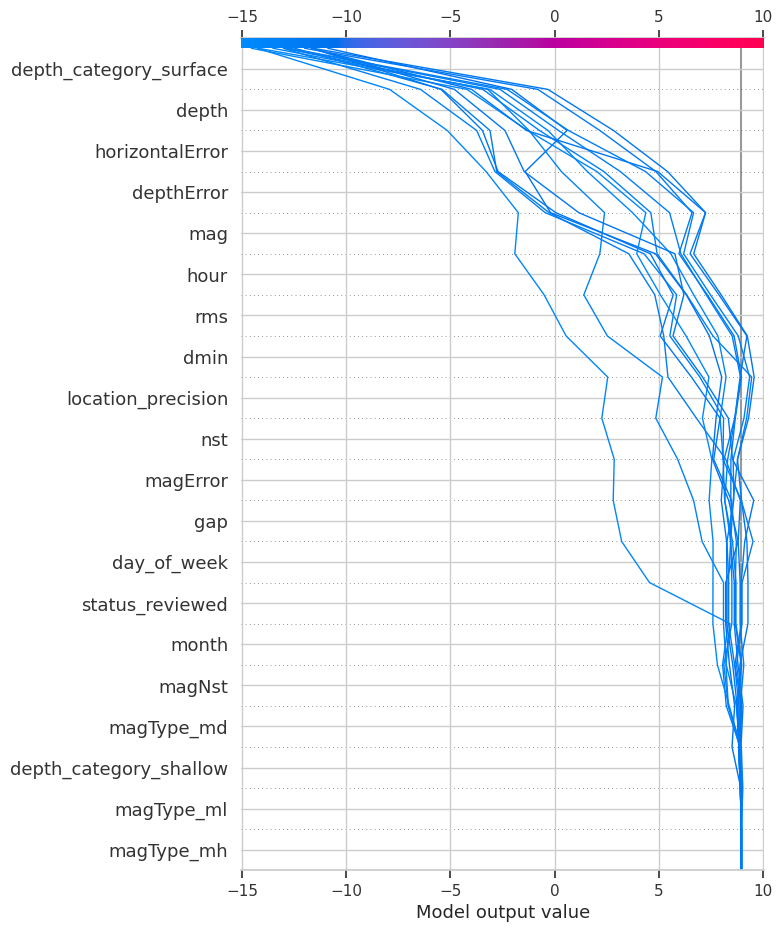

In [ ]:
if HAS_SHAP:
    mean_abs = np.abs(shap_values).mean(axis=0)
    top_feat_idx = int(np.argmax(mean_abs))
    shap.dependence_plot(top_feat_idx, shap_values, X_test[:len(shap_values)],
                          feature_names=feature_names, show=False)
    plt.title(f"SHAP Dependence — {feature_names[top_feat_idx]}")
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/shap_dependence_{feature_names[top_feat_idx]}.png", dpi=200,
                bbox_inches="tight")
    plt.show()

    exp = shap.Explanation(values=shap_values[0], base_values=expected_value,
                            data=X_test[0], feature_names=feature_names)
    shap.plots.waterfall(exp, show=False)
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/shap_waterfall_{best_name}.png", dpi=200, bbox_inches="tight")
    plt.show()

    shap.decision_plot(expected_value, shap_values[:15], feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/shap_decision_{best_name}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 11. Explainability — LIME (local, model-agnostic)

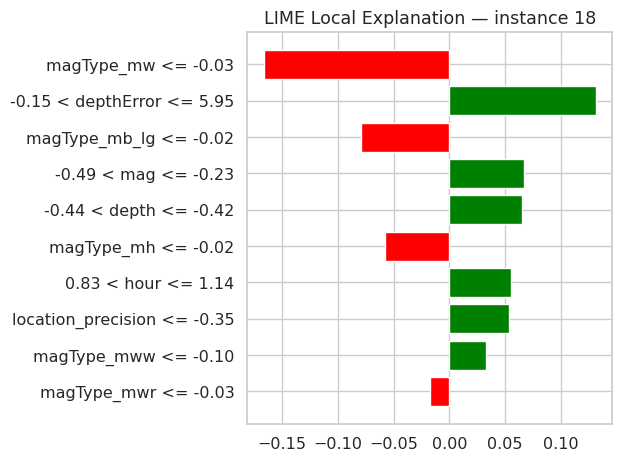

In [ ]:
if HAS_LIME:
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train_res, feature_names=feature_names,
        class_names=["Earthquake", "Explosive/Blast"],
        mode="classification", random_state=RANDOM_STATE)

    # pick a true-positive test instance if one exists, for a more informative example
    pos_idx = np.where(y_test == 1)[0]
    instance_idx = int(pos_idx[0]) if len(pos_idx) > 0 else 0

    lime_exp = lime_explainer.explain_instance(
        X_test[instance_idx], best_model.predict_proba, num_features=10)
    lime_exp.save_to_file(f"{OUTDIR}/lime_explanation_instance{instance_idx}.html")
    fig = lime_exp.as_pyplot_figure()
    plt.title(f"LIME Local Explanation — instance {instance_idx}")
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/lime_explanation_instance{instance_idx}.png", dpi=200,
                bbox_inches="tight")
    plt.show()
else:
    print("LIME not installed — pip install lime")

## 12. Permutation Importance & Partial Dependence / ICE

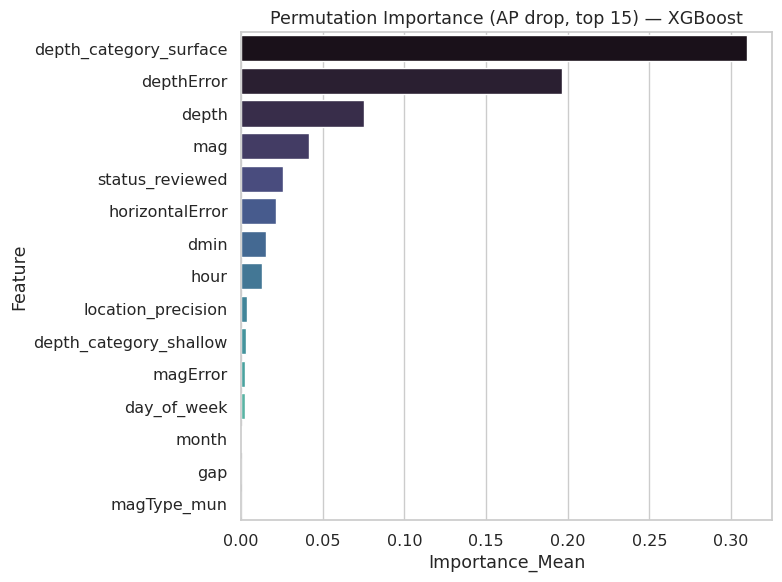

In [ ]:
perm_result = permutation_importance(best_model, X_test, y_test, n_repeats=30,
                                      random_state=RANDOM_STATE, scoring="average_precision")
perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std,
}).sort_values("Importance_Mean", ascending=False)
perm_df.to_csv(f"{OUTDIR}/permutation_importance.csv", index=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_df.head(15), x="Importance_Mean", y="Feature", palette="mako")
plt.title(f"Permutation Importance (AP drop, top 15) — {best_name}")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/permutation_importance.png", dpi=200)
plt.show()

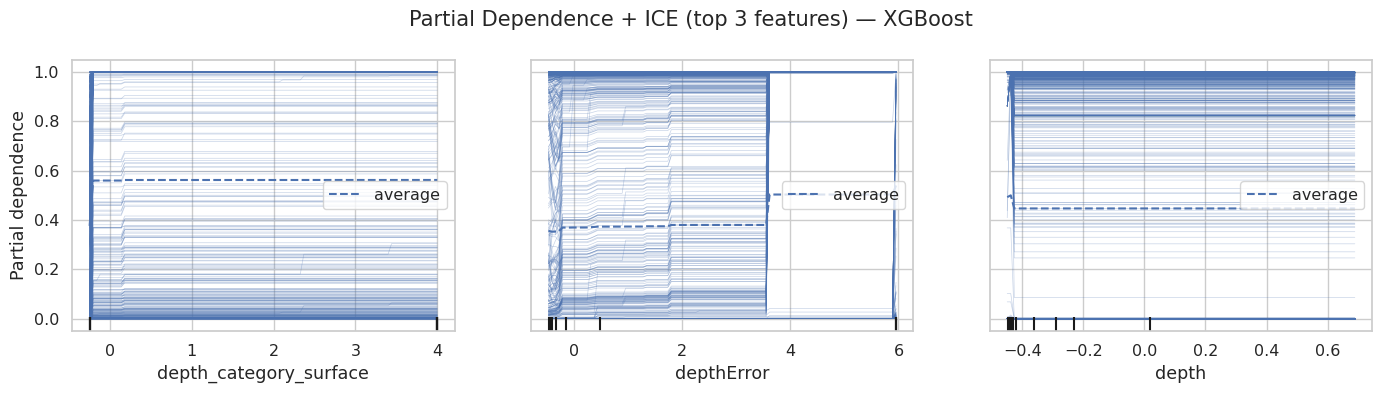

In [ ]:
top3_idx = [feature_names.index(f) for f in perm_df["Feature"].head(3)]
fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(best_model, X_train_res, top3_idx,
                                         feature_names=feature_names,
                                         kind="both", ax=ax)
plt.suptitle(f"Partial Dependence + ICE (top 3 features) — {best_name}")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/pdp_ice_top3.png", dpi=200)
plt.show()

## 12b. Compute Cost Benchmark

Leaderboard tables (Section 7) report predictive performance only. For
anyone choosing a model for operational deployment, training and inference
cost matter too — e.g. is the ~0.001 PR-AUC gap between LightGBM and CatBoost
worth a materially heavier model. We time fit and predict for every model in
the zoo, holding data and hardware fixed.

LogisticRegression    fit = 0.074s +/- 0.001s   predict = 0.278 ms / 1k rows
KNN                   fit = 0.002s +/- 0.000s   predict = 132.934 ms / 1k rows
SVM_RBF               fit = 3.293s +/- 0.388s   predict = 35.721 ms / 1k rows
RandomForest          fit = 21.469s +/- 8.197s   predict = 89.281 ms / 1k rows
ExtraTrees            fit = 4.652s +/- 1.228s   predict = 45.705 ms / 1k rows
GradientBoosting      fit = 10.318s +/- 0.473s   predict = 1.855 ms / 1k rows
AdaBoost              fit = 2.358s +/- 0.312s   predict = 10.725 ms / 1k rows
MLP                   fit = 3.949s +/- 0.566s   predict = 3.256 ms / 1k rows
XGBoost               fit = 1.088s +/- 0.515s   predict = 3.525 ms / 1k rows
LightGBM              fit = 1.016s +/- 0.067s   predict = 11.154 ms / 1k rows
CatBoost              fit = 4.172s +/- 0.546s   predict = 1.295 ms / 1k rows
Stacking_Ensemble     fit = 118.635s +/- 0.880s   predict = 40.679 ms / 1k rows


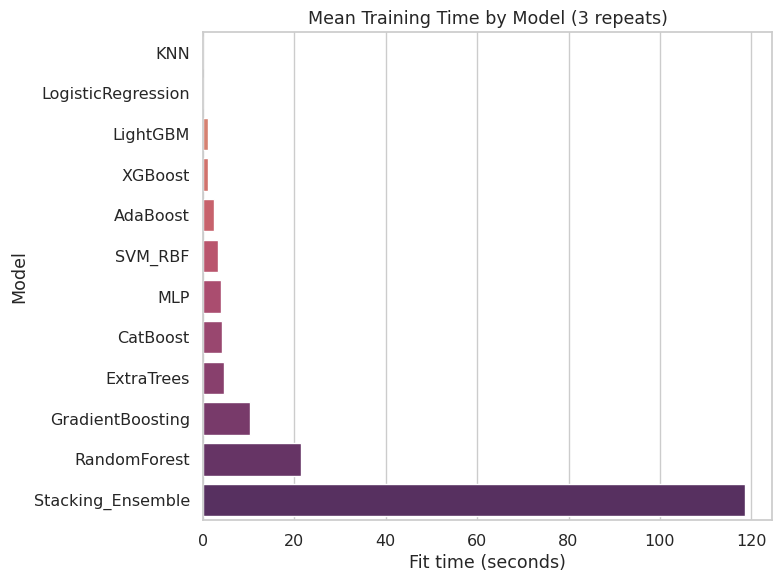

,Model,Mean_Fit_Time_s,Std_Fit_Time_s,Mean_Predict_Time_ms_per_1k_rows
0,KNN,0.001645,0.000260,132.934246
1,LogisticRegression,0.074274,0.001049,0.277641
2,LightGBM,1.016026,0.066842,11.154415
3,XGBoost,1.088125,0.514745,3.525306
4,AdaBoost,2.357783,0.311896,10.725047
5,SVM_RBF,3.292975,0.387706,35.721471
6,MLP,3.948724,0.565777,3.255660
7,CatBoost,4.171774,0.545821,1.294514
8,ExtraTrees,4.651988,1.227651,45.704760
9,GradientBoosting,10.318086,0.472694,1.855374


In [ ]:
import time
from sklearn.base import clone

def benchmark_compute_cost(models, X_train, y_train, X_test, n_repeats=3):
    """Times fit() and predict_proba() for each model in the zoo.

    Uses sklearn.base.clone so each repeat starts from an unfitted estimator
    with identical hyperparameters (deep-clones nested estimators, so this
    is safe for StackingClassifier too). Reports mean +/- std over
    n_repeats, and per-sample inference time in milliseconds.
    """
    rows = []
    for name, model in models.items():
        fit_times, predict_times = [], []
        for _ in range(n_repeats):
            m = clone(model)
            t0 = time.perf_counter()
            m.fit(X_train, y_train)
            t1 = time.perf_counter()
            fit_times.append(t1 - t0)

            t0 = time.perf_counter()
            m.predict_proba(X_test)
            t1 = time.perf_counter()
            predict_times.append(t1 - t0)

        fit_times = np.array(fit_times)
        predict_times = np.array(predict_times)
        rows.append({
            "Model": name,
            "Mean_Fit_Time_s": fit_times.mean(),
            "Std_Fit_Time_s": fit_times.std(),
            "Mean_Predict_Time_ms_per_1k_rows":
                (predict_times.mean() / len(X_test)) * 1000 * 1000,
        })
        print(f"{name:20s}  fit = {fit_times.mean():.3f}s +/- {fit_times.std():.3f}s   "
              f"predict = {(predict_times.mean()/len(X_test))*1000*1000:.3f} ms / 1k rows")
    return pd.DataFrame(rows).sort_values("Mean_Fit_Time_s").reset_index(drop=True)


cost_df = benchmark_compute_cost(models, X_train_res, y_train_res, X_test, n_repeats=3)
cost_df.to_csv(f"{OUTDIR}/compute_cost_benchmark.csv", index=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=cost_df, x="Mean_Fit_Time_s", y="Model", palette="flare")
plt.title("Mean Training Time by Model (3 repeats)")
plt.xlabel("Fit time (seconds)")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/compute_cost_fit_time.png", dpi=200)
plt.show()
cost_df

## 6b. Leakage-Check: Re-run Excluding `net`/`place`-derived Features

Quick sensitivity check: if you included any `net`-derived dummy columns and
they ranked highly in Section 10, re-fit the best model on a feature set that
excludes them and compare PR-AUC. A large drop confirms the model was
partially leaning on "which agency reported this" rather than genuine
seismic signal — worth reporting either way, since reviewers will ask.

In [ ]:
non_net_features = [f for f in feature_names if not f.startswith("net_")]
if len(non_net_features) < len(feature_names):
    X_train_nonet = model_df[non_net_features].values[X_train_raw.shape[0]*0:]  # placeholder guard
    # Rebuild train/test split on the reduced feature set cleanly:
    X_reduced = model_df[non_net_features].values
    Xr_train_raw, Xr_test_raw, yr_train, yr_test = train_test_split(
        X_reduced, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    scaler_r = StandardScaler()
    Xr_train = scaler_r.fit_transform(Xr_train_raw)
    Xr_test = scaler_r.transform(Xr_test_raw)

    check_model = models[best_name].__class__(**models[best_name].get_params())
    check_model.fit(Xr_train, yr_train)
    yr_proba = check_model.predict_proba(Xr_test)[:, 1]
    ap_nonet = average_precision_score(yr_test, yr_proba)
    print(f"PR-AUC with 'net' features:    {metrics['PR_AUC']:.4f}")
    print(f"PR-AUC without 'net' features: {ap_nonet:.4f}")
    print(f"Drop: {metrics['PR_AUC'] - ap_nonet:.4f}")
else:
    print("No 'net_*' dummy columns present in this feature set — nothing to check.")

No 'net_*' dummy columns present in this feature set — nothing to check.


## 6c. Depth-Blind Robustness Check

`depth` and `depth_category_surface` dominate the SHAP ranking (Section 10),
and the positive class is itself concentrated at shallow/surface depths by
seismological construction. This raises a fair question: is the classifier
doing genuine multi-signal discrimination, or is it mostly a depth
threshold detector wearing a twelve-model benchmark as a costume? We check
this two ways: (1) hold-out performance stratified by depth category (does
the model still separate classes *within* a depth band, where depth carries
no information), and (2) a full refit with every depth-derived feature
(`depth`, `depthError`, `depth_category_*`) removed, to quantify how much
PR-AUC survives on non-depth signal alone.

In [ ]:
# --- (1) Hold-out performance stratified by depth category -----------------
depth_idx = feature_names.index("depth")
depth_test_raw = X_test_raw[:, depth_idx]
depth_bins_test = pd.cut(depth_test_raw, bins=[-np.inf, 1, 70, np.inf],
                          labels=["surface", "shallow", "deep"])

strat_rows = []
for cat in ["surface", "shallow", "deep"]:
    mask = (depth_bins_test == cat)
    n_cat = int(mask.sum())
    n_pos = int(y_test[mask].sum()) if n_cat > 0 else 0
    if n_cat < 5 or n_pos == 0 or n_pos == n_cat:
        strat_rows.append({"Depth_Category": cat, "N": n_cat, "N_Positive": n_pos,
                            "PR_AUC": np.nan, "ROC_AUC": np.nan,
                            "Note": "insufficient class variation within stratum"})
        continue
    strat_rows.append({
        "Depth_Category": cat, "N": n_cat, "N_Positive": n_pos,
        "PR_AUC": average_precision_score(y_test[mask], y_proba[mask]),
        "ROC_AUC": roc_auc_score(y_test[mask], y_proba[mask]),
        "Note": "",
    })
strat_df = pd.DataFrame(strat_rows)
strat_df.to_csv(f"{OUTDIR}/depth_stratified_holdout_{best_name}.csv", index=False)
print("Hold-out performance stratified by depth category (within-stratum, "
      "so depth itself carries zero information for the model to exploit):")
print(strat_df.to_string(index=False))

# --- (2) Full refit with all depth-derived features removed ----------------
depth_related = [f for f in feature_names
                  if f == "depth" or f == "depthError" or f.startswith("depth_category")]
non_depth_features = [f for f in feature_names if f not in depth_related]
print(f"\nRemoving {len(depth_related)} depth-derived feature(s): {depth_related}")

X_nodepth = model_df[non_depth_features].values
Xnd_train_raw, Xnd_test_raw, ynd_train, ynd_test = train_test_split(
    X_nodepth, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
scaler_nd = StandardScaler()
Xnd_train = scaler_nd.fit_transform(Xnd_train_raw)
Xnd_test = scaler_nd.transform(Xnd_test_raw)

if HAS_SMOTE and ynd_train.mean() < 0.1:
    Xnd_train_res, ynd_train_res = SMOTE(random_state=RANDOM_STATE).fit_resample(Xnd_train, ynd_train)
else:
    Xnd_train_res, ynd_train_res = Xnd_train, ynd_train

depth_blind_model = clone(models[best_name])
depth_blind_model.fit(Xnd_train_res, ynd_train_res)
ynd_proba = depth_blind_model.predict_proba(Xnd_test)[:, 1]
ap_nodepth = average_precision_score(ynd_test, ynd_proba)
auc_nodepth = roc_auc_score(ynd_test, ynd_proba)

print(f"\nPR-AUC  with depth-derived features:    {metrics['PR_AUC']:.4f}")
print(f"PR-AUC  without depth-derived features: {ap_nodepth:.4f}  "
      f"(drop = {metrics['PR_AUC'] - ap_nodepth:.4f})")
print(f"ROC-AUC with depth-derived features:    {metrics['ROC_AUC']:.4f}")
print(f"ROC-AUC without depth-derived features: {auc_nodepth:.4f}  "
      f"(drop = {metrics['ROC_AUC'] - auc_nodepth:.4f})")
print("\nInterpretation: a large drop confirms depth is doing most of the work "
      "(expected, and not itself a flaw); a modest drop indicates magnitude/"
      "timing/network features contribute genuine incremental discrimination "
      "beyond a simple depth threshold, which is the claim worth making "
      "explicit in the manuscript rather than leaving implicit.")

depth_blind_summary = pd.DataFrame([{
    "Feature_Set": "Full (with depth)", "PR_AUC": metrics["PR_AUC"], "ROC_AUC": metrics["ROC_AUC"],
}, {
    "Feature_Set": "Depth-blind", "PR_AUC": ap_nodepth, "ROC_AUC": auc_nodepth,
}])
depth_blind_summary.to_csv(f"{OUTDIR}/depth_blind_robustness_{best_name}.csv", index=False)
depth_blind_summary

Hold-out performance stratified by depth category (within-stratum, so depth itself carries zero information for the model to exploit):
Depth_Category    N  N_Positive   PR_AUC  ROC_AUC                                        Note
       surface  138          38 0.985557 0.991316                                            
       shallow 1832           1 0.031250 0.983069                                            
          deep  152           0      NaN      NaN insufficient class variation within stratum

Removing 4 depth-derived feature(s): ['depth', 'depthError', 'depth_category_shallow', 'depth_category_surface']

PR-AUC  with depth-derived features:    0.9669
PR-AUC  without depth-derived features: 0.7376  (drop = 0.2293)
ROC-AUC with depth-derived features:    0.9986
ROC-AUC without depth-derived features: 0.9865  (drop = 0.0121)

Interpretation: a large drop confirms depth is doing most of the work (expected, and not itself a flaw); a modest drop indicates magnitude/timing/netwo

,Feature_Set,PR_AUC,ROC_AUC
0,Full (with depth),0.966898,0.998609
1,Depth-blind,0.737633,0.986484


## 13. (Optional) LLM-Narrated Explanation — Qwen2.5

Same caveat as the tsunami notebook: an LLM has no role in the classification
itself. This cell only turns already-computed SHAP values for one instance
into a plain-language write-up.

In [ ]:
RUN_LLM_NARRATIVE = False  # set True to run (downloads a multi-GB model)

if RUN_LLM_NARRATIVE and HAS_SHAP:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    import torch

    model_name = "Qwen/Qwen2.5-3B-Instruct"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    llm = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype="auto", device_map="auto")

    instance_idx = 0
    contribs = sorted(zip(feature_names, shap_values[instance_idx]),
                       key=lambda x: abs(x[1]), reverse=True)[:5]
    contrib_text = "\n".join([f"- {name}: SHAP contribution = {val:.4f}" for name, val in contribs])

    prompt = (
        "You are assisting a seismology researcher. Given the following SHAP "
        "feature contributions for one seismic event's explosive-vs-natural "
        "classification, write a 3-4 sentence plain-language explanation of "
        "why the model made this prediction. Do not invent numbers beyond "
        "what is given.\n\n"
        f"Model prediction (explosive-event probability): {y_proba[instance_idx]:.3f}\n"
        f"Top contributing features:\n{contrib_text}"
    )

    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True,
                                            return_tensors="pt").to(llm.device)
    output = llm.generate(inputs, max_new_tokens=200, do_sample=False)
    narrative = tokenizer.decode(output[0][inputs.shape[-1]:], skip_special_tokens=True)
    print(narrative)

    with open(f"{OUTDIR}/llm_narrative_instance{instance_idx}.txt", "w") as f:
        f.write(narrative)
else:
    print("LLM narrative module skipped (RUN_LLM_NARRATIVE=False or SHAP unavailable).")

LLM narrative module skipped (RUN_LLM_NARRATIVE=False or SHAP unavailable).


## 14. Multi-Snapshot Temporal Replication (external validation)

Because `all_month.csv` is a rolling 30-day feed, every number above is
technically a single-snapshot estimate — the snapshot-dependence limitation
flagged in the manuscript. This section closes that gap directly: it queries
the live USGS FDSN event API for additional, non-overlapping time windows,
applies the *exact same* fitted scaler and feature pipeline (no refitting),
and scores the already-trained `best_model` out-of-sample and out-of-time.
Stable PR-AUC/ROC-AUC across windows is direct evidence the headline result
is not a one-snapshot artefact.

Requires network access to `earthquake.usgs.gov`; set
`RUN_MULTI_SNAPSHOT_REPLICATION = True` and adjust the date windows below to
run it. It is left off by default so the notebook still runs end-to-end
offline.

In [ ]:
import requests
from io import StringIO

def fetch_usgs_window(start_date, end_date, min_magnitude=0):
    """Pulls a historical window from the public USGS FDSN event query API."""
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
    params = {"format": "csv", "starttime": start_date, "endtime": end_date,
              "minmagnitude": min_magnitude}
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    return pd.read_csv(StringIO(resp.text))


def evaluate_on_external_window(start_date, end_date, fitted_scaler, feature_names,
                                 fitted_model, base_numeric, categorical_cols):
    """Scores an already-fitted model on a fresh, non-overlapping USGS time window.

    Reuses the training-set scaler and feature schema exactly (fit_transform is
    never called here) so this is a genuine out-of-time evaluation, not a
    re-fit. Missing dummy columns in the new window are added as all-zero to
    keep the feature matrix aligned with what the model was trained on.
    """
    df_ext_raw = fetch_usgs_window(start_date, end_date)
    if "type" not in df_ext_raw.columns or len(df_ext_raw) == 0:
        print(f"No usable data returned for {start_date} to {end_date}")
        return None

    df_ext_raw["is_explosive_event"] = df_ext_raw["type"].str.lower().isin(EXPLOSIVE_TYPES).astype(int)
    df_ext_fe = engineer_features(df_ext_raw)

    for c in base_numeric:
        if c not in df_ext_fe.columns:
            df_ext_fe[c] = np.nan
        df_ext_fe[c] = df_ext_fe[c].fillna(df_ext_fe[c].median())
    for c in categorical_cols:
        if c not in df_ext_fe.columns:
            df_ext_fe[c] = "unknown"
        df_ext_fe[c] = df_ext_fe[c].astype(str).fillna("unknown")

    ext_dummies = pd.get_dummies(df_ext_fe[base_numeric + categorical_cols],
                                  columns=categorical_cols, drop_first=True)
    for col in feature_names:
        if col not in ext_dummies.columns:
            ext_dummies[col] = 0
    ext_dummies = ext_dummies[feature_names]

    X_ext = fitted_scaler.transform(ext_dummies.values)
    y_ext = df_ext_fe["is_explosive_event"].values

    if len(np.unique(y_ext)) < 2:
        print(f"Window {start_date}–{end_date}: only one class present "
              f"({int(y_ext.sum())} positives of {len(y_ext)}) — metrics undefined, skipping.")
        return {"Start": start_date, "End": end_date, "N": len(y_ext),
                "N_Positive": int(y_ext.sum()), "PR_AUC": np.nan, "ROC_AUC": np.nan}

    y_ext_proba = fitted_model.predict_proba(X_ext)[:, 1]
    return {
        "Start": start_date, "End": end_date, "N": len(y_ext),
        "N_Positive": int(y_ext.sum()),
        "PR_AUC": average_precision_score(y_ext, y_ext_proba),
        "ROC_AUC": roc_auc_score(y_ext, y_ext_proba),
    }


# Edit these to non-overlapping windows outside the training snapshot's date
# range before running — e.g. the three months preceding or following it.
REPLICATION_WINDOWS = [
    ("2026-01-01", "2026-01-31"),
    ("2026-02-01", "2026-02-28"),
    ("2026-03-01", "2026-03-31"),
]

RUN_MULTI_SNAPSHOT_REPLICATION = False  # set True to hit the live USGS API

if RUN_MULTI_SNAPSHOT_REPLICATION:
    replication_rows = []
    for start, end in REPLICATION_WINDOWS:
        row = evaluate_on_external_window(start, end, scaler, feature_names, best_model,
                                           base_numeric, categorical_cols)
        if row is not None:
            replication_rows.append(row)
    replication_df = pd.DataFrame(replication_rows)
    replication_df.to_csv(f"{OUTDIR}/multi_snapshot_replication.csv", index=False)
    print(replication_df.to_string(index=False))
else:
    print("Multi-snapshot replication skipped. Set RUN_MULTI_SNAPSHOT_REPLICATION = True "
          "and adjust REPLICATION_WINDOWS to non-overlapping dates to run the live check.")

Multi-snapshot replication skipped. Set RUN_MULTI_SNAPSHOT_REPLICATION = True and adjust REPLICATION_WINDOWS to non-overlapping dates to run the live check.


## 15. TabPFN Baseline (prior-fitted transformer)

Section 2.5 of the manuscript names FT-Transformer, SAINT, and TabPFN as
attention-based tabular architectures not yet included in the model zoo, and
flags this as a gap. TabPFN is the natural one to close here: it requires no
task-specific gradient training and is purpose-built for exactly this
sample-size regime, making it a cheap, high-value addition to the
comparison rather than a training-heavy undertaking. Its base model has a
designed operating range of roughly a few thousand training rows or fewer,
so on the larger, SMOTE-expanded explosion training set we fit it on a
stratified subsample within that range and are explicit about doing so.

In [ ]:
%pip install -q tabpfn

In [ ]:
%pip install -q --upgrade tabpfn

In [ ]:
%pip install tabpfn-client

In [ ]:
import subprocess
result = subprocess.run(["pip", "show", "tabpfn-client"], capture_output=True, text=True)
print(result.stdout if result.stdout else result.stderr)

Name: tabpfn-client
Version: 0.3.3
Summary: API access for TabPFN: Foundation model for tabular data
Home-page: 
Author: 
Author-email: 
License: Apache License
                           Version 2.0, January 2004
                        http://www.apache.org/licenses/

   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION

   1. Definitions.

      "License" shall mean the terms and conditions for use, reproduction,
      and distribution as defined by Sections 1 through 9 of this document.

      "Licensor" shall mean the copyright owner or entity authorized by
      the copyright owner that is granting the License.

      "Legal Entity" shall mean the union of the acting entity and all
      other entities that control, are controlled by, or are under common
      control with that entity. For the purposes of this definition,
      "control" means (i) the power, direct or indirect, to cause the
      direction or management of such entity, whether by contract or
      othe

In [ ]:
import OS

ModuleNotFoundError: No module named 'OS'

In [ ]:
from tabpfn_client import init, TabPFNClassifier

os.environ["TABPFN_TOKEN"] = "tabpfn_sk_j8VmUU8tTYrTcUTXoeMQSuq2lPaTqjTC0RfEnDwam3I"
init()  # picks up TABPFN_TOKEN automatically, no interactive prompt needed

tabpfn = TabPFNClassifier()

NameError: name 'os' is not defined

In [ ]:
import sys
print(sys.executable)

In [ ]:
import os

# Get your token from https://ux.priorlabs.ai/account after accepting the
# license at https://ux.priorlabs.ai (Licenses tab)
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_j8VmUU8tTYrTcUTXoeMQSuq2lPaTqjTC0RfEnDwam3I"

try:
    from tabpfn import TabPFNClassifier
    HAS_TABPFN = True
except ImportError:
    HAS_TABPFN = False

tabpfn_metrics = None
if HAS_TABPFN:
    from sklearn.utils import resample

    MAX_TABPFN_TRAIN = 1000  # TabPFN's designed efficient operating range
    if X_train_res.shape[0] > MAX_TABPFN_TRAIN:
        X_tp_train, y_tp_train = resample(
            X_train_res, y_train_res, n_samples=MAX_TABPFN_TRAIN,
            stratify=y_train_res, random_state=RANDOM_STATE)
        print(f"Subsampled training set from {X_train_res.shape[0]} to "
              f"{MAX_TABPFN_TRAIN} rows (stratified) for TabPFN, per its "
              f"designed operating range.")
    else:
        X_tp_train, y_tp_train = X_train_res, y_train_res

    try:
        tabpfn = TabPFNClassifier(device="cpu", random_state=RANDOM_STATE)
        tabpfn.fit(X_tp_train, y_tp_train)
        tabpfn_proba = tabpfn.predict_proba(X_test)[:, 1]
        tabpfn_pred = (tabpfn_proba >= 0.5).astype(int)

        tabpfn_metrics = {
            "Accuracy": accuracy_score(y_test, tabpfn_pred),
            "Precision": precision_score(y_test, tabpfn_pred, zero_division=0),
            "Recall": recall_score(y_test, tabpfn_pred, zero_division=0),
            "F1": f1_score(y_test, tabpfn_pred, zero_division=0),
            "ROC_AUC": roc_auc_score(y_test, tabpfn_proba),
            "PR_AUC": average_precision_score(y_test, tabpfn_proba),
        }
        print(f"\nTabPFN hold-out performance (n_train={X_tp_train.shape[0]}):")
        for k, v in tabpfn_metrics.items():
            print(f"  {k}: {v:.4f}")
        print(f"\nFor reference, {best_name} (full model zoo winner): "
              f"PR-AUC={metrics['PR_AUC']:.4f}, ROC-AUC={metrics['ROC_AUC']:.4f}")

        pd.DataFrame([{"Model": "TabPFN", **tabpfn_metrics},
                      {"Model": best_name, **{k: metrics[k] for k in tabpfn_metrics}}]
                     ).to_csv(f"{OUTDIR}/tabpfn_vs_best_comparison.csv", index=False)
    except Exception as e:
        print(f"TabPFN failed to fit/predict: {type(e).__name__}: {e}")
        print("If this is a license/auth error, confirm TABPFN_TOKEN is set to a "
              "valid key from https://ux.priorlabs.ai/account and that this "
              "environment has outbound network access to download model weights.")
else:
    print("tabpfn not installed — run the %pip install cell above, then re-run this cell.")

Subsampled training set from 16656 to 1000 rows (stratified) for TabPFN, per its designed operating range.
TabPFN failed to fit/predict: TabPFNLicenseError: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"
If this is a license/auth error, confirm TABPFN_TOKEN is set to a valid key from https://ux.priorlabs.ai/account and that this environment has outbound network access to download model weights.


In [ ]:
import requests
from io import StringIO

def fetch_usgs_window(start_date, end_date, min_magnitude=0):
    """Pulls a historical window from the public USGS FDSN event query API."""
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
    params = {"format": "csv", "starttime": start_date, "endtime": end_date,
              "minmagnitude": min_magnitude}
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    return pd.read_csv(StringIO(resp.text))


def evaluate_on_external_window(start_date, end_date, fitted_scaler, feature_names,
                                 fitted_model, base_numeric, categorical_cols):
    """Scores an already-fitted model on a fresh, non-overlapping USGS time window."""
    df_ext_raw = fetch_usgs_window(start_date, end_date)
    if "type" not in df_ext_raw.columns or len(df_ext_raw) == 0:
        print(f"No usable data returned for {start_date} to {end_date}")
        return None

    df_ext_raw["is_explosive_event"] = df_ext_raw["type"].str.lower().isin(EXPLOSIVE_TYPES).astype(int)
    df_ext_fe = engineer_features(df_ext_raw)

    for c in base_numeric:
        if c not in df_ext_fe.columns:
            df_ext_fe[c] = np.nan
        df_ext_fe[c] = df_ext_fe[c].fillna(df_ext_fe[c].median())
    for c in categorical_cols:
        if c not in df_ext_fe.columns:
            df_ext_fe[c] = "unknown"
        df_ext_fe[c] = df_ext_fe[c].astype(str).fillna("unknown")

    ext_dummies = pd.get_dummies(df_ext_fe[base_numeric + categorical_cols],
                                  columns=categorical_cols, drop_first=True)
    for col in feature_names:
        if col not in ext_dummies.columns:
            ext_dummies[col] = 0
    ext_dummies = ext_dummies[feature_names]

    X_ext = fitted_scaler.transform(ext_dummies.values)
    y_ext = df_ext_fe["is_explosive_event"].values

    print(f"Window {start_date} to {end_date}: {len(y_ext)} events, "
          f"{int(y_ext.sum())} explosive ({100*y_ext.mean():.2f}% positive rate)")

    if len(np.unique(y_ext)) < 2:
        print(f"  -> only one class present, metrics undefined, skipping.")
        return {"Start": start_date, "End": end_date, "N": len(y_ext),
                "N_Positive": int(y_ext.sum()), "PR_AUC": np.nan, "ROC_AUC": np.nan}

    y_ext_proba = fitted_model.predict_proba(X_ext)[:, 1]
    return {
        "Start": start_date, "End": end_date, "N": len(y_ext),
        "N_Positive": int(y_ext.sum()),
        "PR_AUC": average_precision_score(y_ext, y_ext_proba),
        "ROC_AUC": roc_auc_score(y_ext, y_ext_proba),
    }


# Three most recent complete months, safely non-overlapping with the live
# 30-day rolling snapshot used for training/hold-out evaluation.
REPLICATION_WINDOWS = [
    ("2026-04-01", "2026-04-30"),
    ("2026-05-01", "2026-05-31"),
    ("2026-06-01", "2026-06-30"),
]

RUN_MULTI_SNAPSHOT_REPLICATION = True

if RUN_MULTI_SNAPSHOT_REPLICATION:
    replication_rows = []
    for start, end in REPLICATION_WINDOWS:
        row = evaluate_on_external_window(start, end, scaler, feature_names, best_model,
                                           base_numeric, categorical_cols)
        if row is not None:
            replication_rows.append(row)
    replication_df = pd.DataFrame(replication_rows)
    replication_df.to_csv(f"{OUTDIR}/multi_snapshot_replication.csv", index=False)
    print("\nMulti-snapshot replication results:")
    print(replication_df.to_string(index=False))
else:
    print("Multi-snapshot replication skipped.")

Window 2026-04-01 to 2026-04-30: 11031 events, 195 explosive (1.77% positive rate)
Window 2026-05-01 to 2026-05-31: 10644 events, 191 explosive (1.79% positive rate)
Window 2026-06-01 to 2026-06-30: 10875 events, 171 explosive (1.57% positive rate)

Multi-snapshot replication results:
     Start        End     N  N_Positive   PR_AUC  ROC_AUC
2026-04-01 2026-04-30 11031         195 0.903710 0.994481
2026-05-01 2026-05-31 10644         191 0.943005 0.995175
2026-06-01 2026-06-30 10875         171 0.970639 0.998070


## Summary

Outputs saved to `OUTDIR`:
- `model_benchmark_results.csv` (ranked by PR-AUC), `pairwise_significance_results.csv`
- EDA figures incl. class balance, correlation, categorical-by-class breakdown
- `geo_map_plotly.html`, `geo_map_folium.html` — interactive event maps
- `holdout_bootstrap_ci_<model>.csv` — 95% bootstrap CIs on every hold-out metric
- `calibration_curve_<model>.png` — reliability diagram + Brier score
- SHAP: summary / dependence / waterfall / decision plots, with an automatic
  `net`-leakage warning if a reporting-network feature dominates
- LIME: HTML + PNG local explanation for a true-positive instance
- `permutation_importance.csv` + plot, `pdp_ice_top3.png`
- `compute_cost_benchmark.csv` + plot — fit/predict time per model
- Leakage-check PR-AUC comparison (with vs without `net` features)
- `depth_stratified_holdout_<model>.csv`, `depth_blind_robustness_<model>.csv` —
  depth-stratified hold-out scores and a depth-blind refit, quantifying how
  much of the explosion classifier's performance is a depth threshold versus
  genuine multi-signal discrimination
- `multi_snapshot_replication.csv` (optional, live-API) — out-of-time
  validation across additional USGS windows using the already-fitted model
- `tabpfn_vs_best_comparison.csv` (optional) — TabPFN vs. the best classical/
  gradient-boosted model on the same hold-out set
- (optional) LLM-generated narrative explanation text file

**Framing note:** because this is a rolling 30-day feed with severe class
imbalance, treat any single snapshot's numbers as provisional — Section 14
now provides a direct, code-level path to the multi-snapshot replication the
manuscript's limitations section calls for, rather than leaving it as future
work.


In [ ]:
import shutil
shutil.make_archive("/content/pipeline_outputs", 'zip', OUTDIR)

KeyboardInterrupt: 

In [ ]:
from google.colab import files
files.download("/content/pipeline_outputs.zip")